# Complete RAG Pipeline from Scratch
This notebook demonstrates how to build a full Retrieval-Augmented Generation (RAG) pipeline using LangChain, Google Generative AI (Gemini), and FAISS as the vector database.

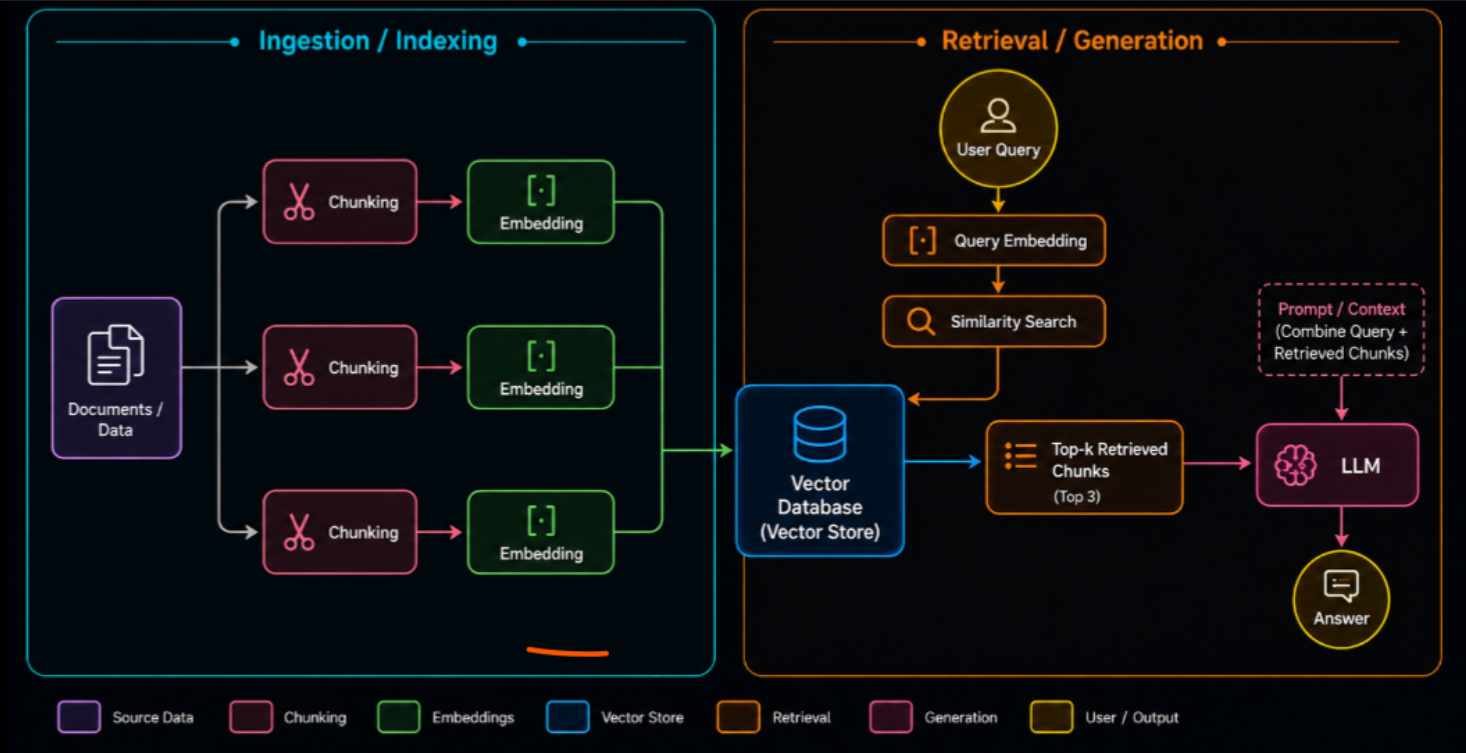

## 1. Setup and Environment Variables
Load the API keys required for Google Generative AI and optionally Groq from the `.env` file.

In [1]:
# Import os module for environment variables
import os

In [2]:
# Load environment variables from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Set Google API Key
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [4]:
# Set Groq API Key (if used later)
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

## 2. Initialize Embeddings Model
We will use `GoogleGenerativeAIEmbeddings` to convert text into vector embeddings.

In [5]:
# Import the Google embeddings class
from langchain_google_genai import GoogleGenerativeAIEmbeddings

d:\Coding\Full-Stack-GenAI-AgenticAI-Bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Initialize the embedding model (gemini-embedding-2)
embeddings = GoogleGenerativeAIEmbeddings(model = 'gemini-embedding-2')

In [37]:
# Test the embedding model with a simple query
embeddings.aembed_query("Hello")

<coroutine object GoogleGenerativeAIEmbeddings.aembed_query at 0x0000021E3008FBA0>

## 3. Initialize Language Model (LLM)
Set up the core Language Model that will generate our final responses. Here we use `gemini-3.1-flash-lite`.

In [8]:
# Import ChatGoogleGenerativeAI
from langchain_google_genai import ChatGoogleGenerativeAI

In [17]:
# Initialize the LLM
llm = ChatGoogleGenerativeAI(model = 'gemini-3.1-flash-lite')

In [18]:
# Test the LLM model to verify it's working
llm.invoke('Hi How are you?').content

[{'type': 'text',
  'text': "I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?",
  'extras': {'signature': 'EjQKMgERTTIP4iaew7VikPbF7MgGH4sUEqmfEaAbAJRJIZhQNnB7hmpBPjky7SUGWgnXDy8r'}}]

## 4. Simple Chatbot (Without RAG)
Before building RAG, let's see how a simple AI Assistant behaves with just the LLM memory and base knowledge.

In [19]:
# A simple interactive chat loop
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chat. Goodbye!")
        break
    response = llm.invoke(user_input).content
    print(f"AI: {response}")

AI: [{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EjQKMgERTTIPT6yE33AmLxTFHDPP0Drq7QWqlGMzKYi+s1m62lO0PSCc6yQ0/B2W5cBLdRhB'}}]
Exiting the chat. Goodbye!


## 5. Document Loading
Now we start the RAG process by loading an external document into memory. We will use `PyPDFLoader` to read a research paper.

In [20]:
# Import LangChain document loaders
from langchain_community.document_loaders import TextLoader, DirectoryLoader, WebBaseLoader, PyPDFLoader

C:\Users\ahmad\AppData\Local\Temp\ipykernel_23608\861452591.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader, DirectoryLoader, WebBaseLoader, PyPDFLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [21]:
# Define the path to the PDF document
file_path = r"D:\Coding\Full-Stack-GenAI-AgenticAI-Bootcamp\05_RAG\02_RAG_Pipeline\deepseek-v4-2026.pdf"

In [22]:
# Load the PDF file into a list of Document objects (one per page)
pages = PyPDFLoader(file_path).load()

In [23]:
# Check the total number of pages loaded
len(pages)

58

## 6. Text Chunking
Since language models have context limits, we split the loaded pages into smaller chunks using `RecursiveCharacterTextSplitter`.

In [24]:
# Import text splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [25]:
# Initialize chunker with 3000 chars size and 200 chars overlap to preserve context
chunker = RecursiveCharacterTextSplitter(chunk_size=3000, chunk_overlap=200)

In [26]:
# Split the loaded pages into chunks
chunked_data = chunker.split_documents(pages)

In [27]:
# Check the total number of chunks created
len(chunked_data)

91

In [28]:
# Inspect the first chunk Document
chunked_data[0]

Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Che

In [29]:
# Inspect the metadata of the first chunk (page number, source file)
chunked_data[0].metadata

{'producer': 'pikepdf 8.15.1',
 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)',
 'creationdate': '',
 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Chen; Jingli Zhou;

In [30]:
# View the actual text content of the first chunk
chunked_data[0].page_content

'DeepSeek-V4:\nTowards Highly Efficient Million-Token Context Intelligence\nDeepSeek-AI\nresearch@deepseek.com\nAbstract\nWe present a preview version of DeepSeek-V4 series, including two strong Mixture-of-\nExperts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and\nDeepSeek-V4-Flash with 284B parameters (13B activated) — both supporting a context length of\none million tokens. DeepSeek-V4 series incorporate several key upgrades in architecture and op-\ntimization: (1) a hybrid attention architecture that combines Compressed Sparse Attention (CSA)\nand Heavily Compressed Attention (HCA) to improve long-context efficiency; (2) Manifold-\nConstrained Hyper-Connections (mHC) that enhance conventional residual connections; (3)\nand the Muon optimizer for faster convergence and greater training stability. We pre-train\nboth models on more than 32T diverse and high-quality tokens, followed by a comprehensive\npost-training pipeline that unlocks and further enha

## 7. Vector Database Setup (FAISS)
We need to store the chunk embeddings in a vector database for efficient semantic search. We will use FAISS (Facebook AI Similarity Search) running locally.

In [31]:
# Import FAISS and InMemoryDocstore
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

In [40]:
# Create a FAISS index using L2 distance (Euclidean). 3072 is the dimension for Google's embedding model.
index = faiss.IndexFlatL2(3072)

In [41]:
# Initialize the FAISS vector store with our embeddings and index
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={}
)

### Add Documents to Vector Store (with Rate Limiting)
To avoid hitting API rate limits during bulk embedding, we add documents in small batches with pauses.

In [42]:
import time
# Reduce batch size to keep token count per minute manageable
batch_size = 20 
for i in range(0, len(chunked_data), batch_size):
    print(f"Adding batch {i} to {i+batch_size} of {len(chunked_data)}...")
    batch = chunked_data[i:i+batch_size]
    
    success = False
    while not success:
        try:
            vector_store.add_documents(batch)
            success = True
            # Normal delay between successful batches
            if i + batch_size < len(chunked_data):
                time.sleep(15) 
        except Exception as e:
            error_msg = str(e)
            if '429' in error_msg or 'RESOURCE_EXHAUSTED' in error_msg:
                print("Rate limit hit! Pausing for 60 seconds before retrying...")
                time.sleep(60)
            else:
                # If it's a different error, raise it
                raise e
print("All documents added successfully!")

Adding batch 0 to 20 of 91...
Adding batch 20 to 40 of 91...
Adding batch 40 to 60 of 91...
Adding batch 60 to 80 of 91...
Adding batch 80 to 100 of 91...
Rate limit hit! Pausing for 60 seconds before retrying...
All documents added successfully!


## 8. Retriever Configuration
Convert the vector store into a retriever interface. When queried, it will fetch the top `k` most similar chunks.

In [43]:
# Create a retriever fetching the top 3 most relevant chunks
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [44]:
# Test the retriever with a query
retriever.invoke("what is this deepseek-v4-2026 model about?")

[Document(id='edde25e9-fe68-41cf-b2a9-4d276da79a8b', metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; 

In [45]:
# Check the text content of the most relevant retrieved chunk
retriever.invoke("what is a release date of deepseek v4 research paper?")[0].page_content

'DeepSeek-V4:\nTowards Highly Efficient Million-Token Context Intelligence\nDeepSeek-AI\nresearch@deepseek.com\nAbstract\nWe present a preview version of DeepSeek-V4 series, including two strong Mixture-of-\nExperts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and\nDeepSeek-V4-Flash with 284B parameters (13B activated) — both supporting a context length of\none million tokens. DeepSeek-V4 series incorporate several key upgrades in architecture and op-\ntimization: (1) a hybrid attention architecture that combines Compressed Sparse Attention (CSA)\nand Heavily Compressed Attention (HCA) to improve long-context efficiency; (2) Manifold-\nConstrained Hyper-Connections (mHC) that enhance conventional residual connections; (3)\nand the Muon optimizer for faster convergence and greater training stability. We pre-train\nboth models on more than 32T diverse and high-quality tokens, followed by a comprehensive\npost-training pipeline that unlocks and further enha

## 9. Define the RAG Prompt
Create a prompt template that strictly instructs the LLM to answer using *only* the retrieved context.

In [46]:
# Import PromptTemplate
from langchain_core.prompts import PromptTemplate

In [47]:
# Define the template with {context} and {question} placeholders
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""

In [48]:
# Instantiate the PromptTemplate
prompt=PromptTemplate.from_template(template)
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n{context}\n\nQuestion: {question}\n')

## 10. Build and Run the RAG Chain
Using LangChain Expression Language (LCEL), we chain together the retriever, prompt, LLM, and output parser into a single pipeline.

In [49]:
# Import output parser and passthrough runnable
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

In [50]:
# Helper function to combine multiple retrieved documents into a single string
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

In [51]:
# Build the LCEL RAG chain
# 1. Fetch context and pass question
# 2. Format into prompt
# 3. Send to LLM
# 4. Parse string output
rag_chain = {"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser()

### Execute RAG Query
Test the full RAG pipeline by asking a specific question related to the uploaded document.

In [52]:
# Invoke the chain to get the final grounded answer
rag_chain.invoke("what is a release date of DeepSeek-V4 research paper?")

'Based on the provided text, the release date of the DeepSeek-V4 research paper is April 26, 2026.'